In [80]:
# Importing Required Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
pd.set_option('display.max_columns',200)


In [81]:
#Importing Train dataset for EDA and Model training
df_train=pd.read_csv('../Logistic Regression Requirements/Titanic_train.csv')
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 1. Data Exploration

In [82]:
# Checking number of rows and columns
df_train.shape

(891, 12)

In [83]:
# Checking columns 
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [84]:
# Checking datatypes of columns
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [85]:
# Understanding statistical Info
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [86]:
# Removing Unnecessary Columns
df_train.drop(columns={'PassengerId','Name','Ticket','Cabin'},axis=1,inplace=True)

In [87]:
# Checking Datatypes of columns were correct or not
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


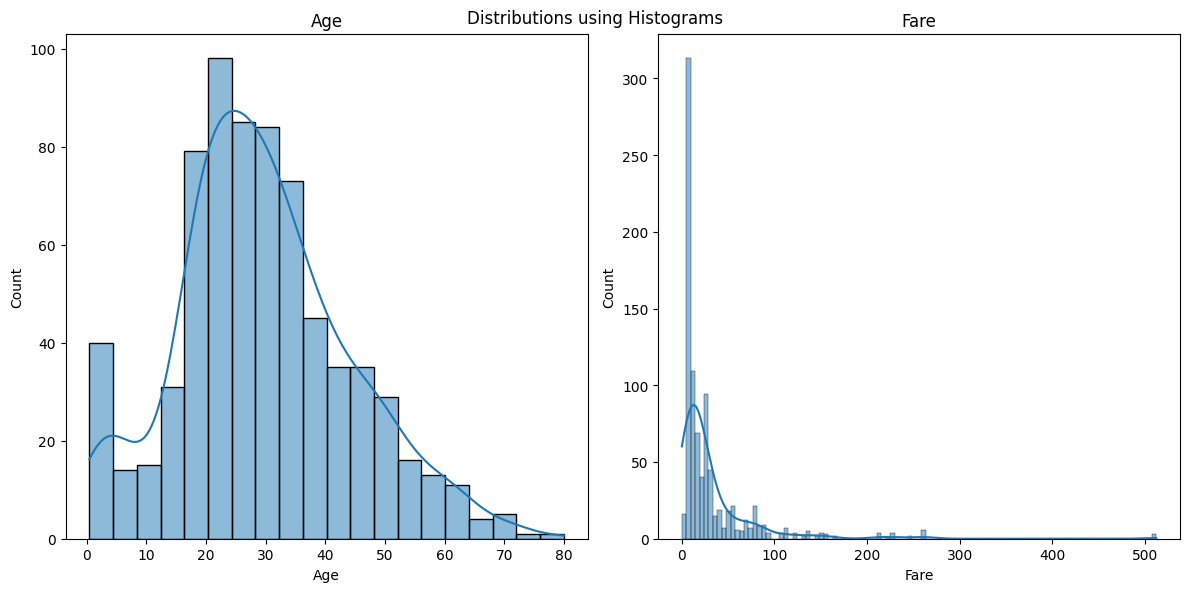

In [88]:
# Understanding about distributions using Histogram
plt.figure(figsize=(12,6))

# Checking for Age
plt.subplot(1,2,1)
sns.histplot(df_train["Age"],kde=True)
plt.title("Age")

# Checking for Price
plt.subplot(1,2,2)
sns.histplot(df_train["Fare"],kde=True)
plt.title("Fare")

plt.tight_layout()
plt.suptitle("Distributions using Histograms")
plt.show()

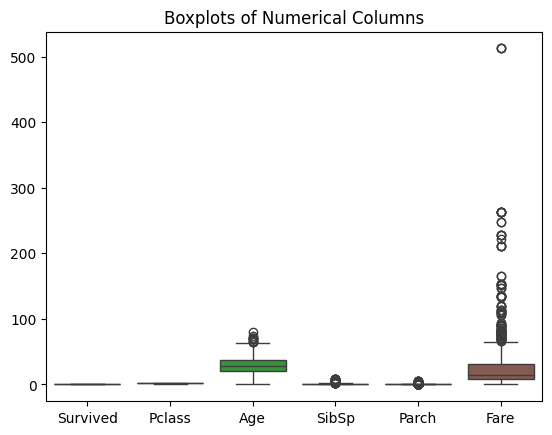

In [89]:
# Checking for outliers using boxplots
sns.boxplot(data=df_train)
plt.title("Boxplots of Numerical Columns")
plt.show()

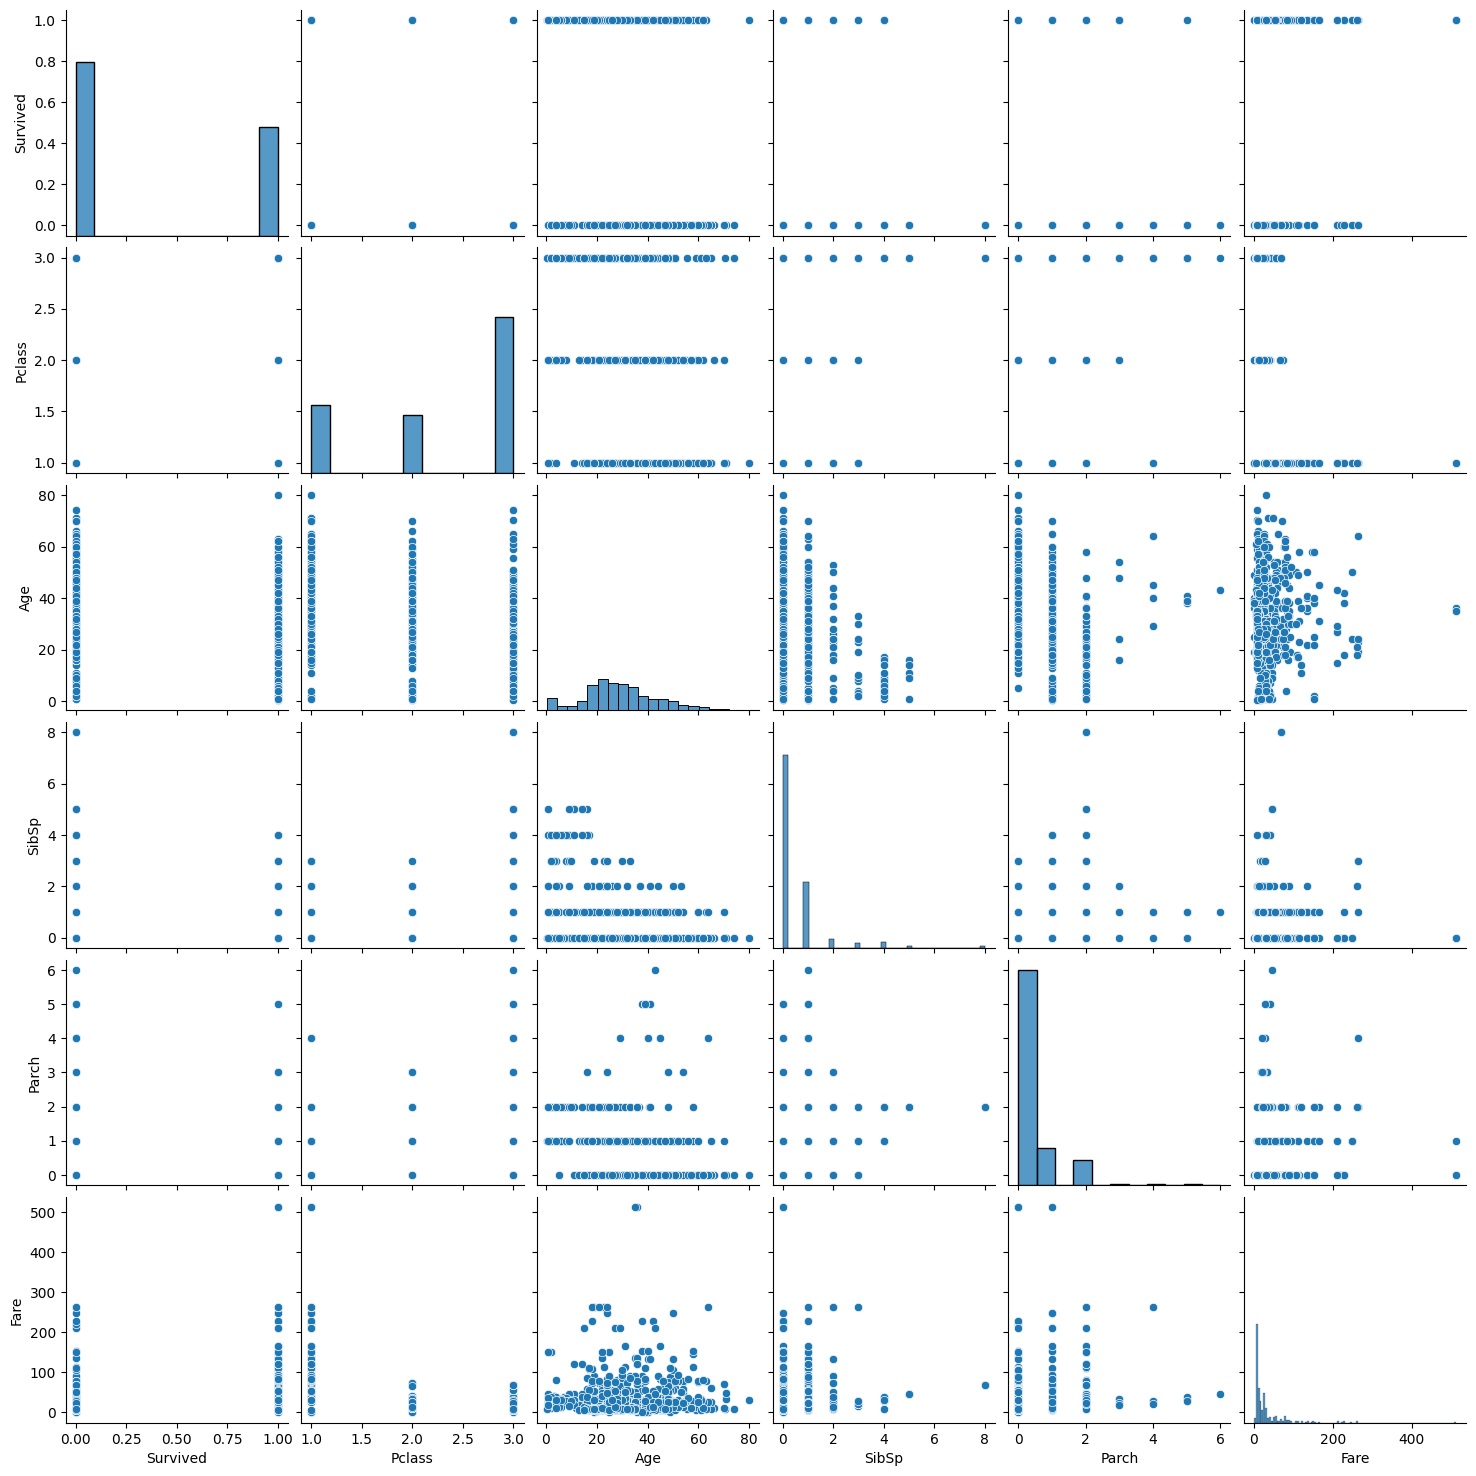

In [90]:
# Pairplot of Train Data
sns.pairplot(data=df_train)
plt.show()

### 2. Data Preprocessing

In [91]:
# Checking for Null Values
df_train.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [92]:
# Filling null values of Age with median
df_train["Age"].fillna(df_train["Age"].median(),inplace=True)

In [93]:
# Filling null values of Embarked using Mode
df_train["Embarked"].fillna(df_train["Embarked"].mode()[0],inplace=True)

In [94]:
# Checking Null Values again
df_train.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [95]:
# Checking for duplicate records
df_train.duplicated().sum()

116

In [96]:
# Dropping duplicates
df_train.drop_duplicates(inplace=True)

In [97]:
# Checking shape
df_train.shape

(775, 8)

In [98]:
# Treating outlier values
import numpy as np

df_train["Fare"] = np.log1p(df_train["Fare"])
#This reduces the effect of large Fare values.

In [99]:
# Encode Categorical Variables
# Encoding Sex
df_train["Sex"]=df_train["Sex"].map({'male':0,'female':1})

In [100]:
# Encoding Embarked
df_train = pd.get_dummies(df_train, columns=["Embarked"],drop_first=True)

In [101]:
df_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,2.110213,False,True
1,1,1,1,38.0,1,0,4.280593,False,False
2,1,3,1,26.0,0,0,2.188856,False,True
3,1,1,1,35.0,1,0,3.990834,False,True
4,0,3,0,35.0,0,0,2.202765,False,True


### 3. Model Building

In [102]:
# Importing Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [103]:
# Define Features (X) and Target (y)
X = df_train.drop("Survived", axis=1)
y = df_train["Survived"]

In [104]:
# Split Data into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [106]:
# Creating Logistic Regression model and training it
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [109]:
# Making Predictions
y_pred = model.predict(X_test)

### 4. Model Evaluation

In [110]:
# Import Evaluation Libraries
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve

In [111]:
# Calculate Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7806451612903226
Precision: 0.7166666666666667
Recall: 0.7166666666666667
F1 Score: 0.7166666666666667


In [112]:
# Calculate ROC-AUC Score
y_prob = model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8514035087719298


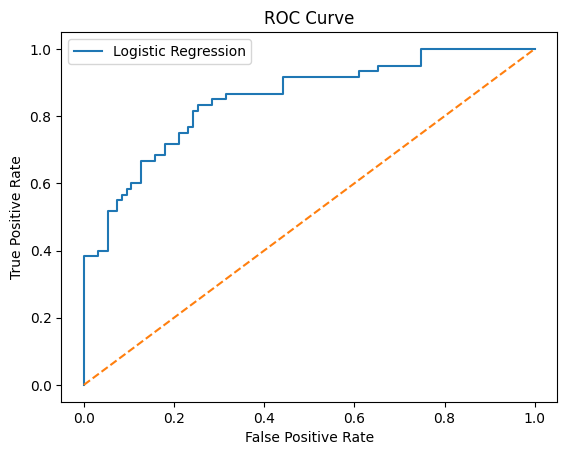

In [113]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'--')  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### 5.Interpretation

In [114]:
# Interpret the Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients)

      Feature  Coefficient
0      Pclass    -0.979216
1         Sex     2.208146
2         Age    -0.040028
3       SibSp    -0.439073
4       Parch    -0.079167
5        Fare     0.188933
6  Embarked_Q    -0.407580
7  Embarked_S    -0.399384


### Significance of Features in Predicting Survival

The model identified several features that influence passenger survival:

- **Sex:** One of the most significant predictors. Female passengers had a much higher survival rate compared to males.
- **Passenger Class (Pclass):** Passengers in first class had better chances of survival compared to second and third class passengers.
- **Age:** Younger passengers had slightly higher survival probability.
- **Fare:** Passengers who paid higher fares often belonged to higher classes, which increased their survival chances.
- **Embarked:** The port of embarkation had a smaller influence compared to other features.

Overall, the model suggests that **gender, passenger class, and age** were the most important factors affecting survival probability in the Titanic dataset.

### 6. Deployment with Streamlit

In [115]:
#Save Your Trained Model
import joblib
joblib.dump(model, "titanic_model.pkl")

['titanic_model.pkl']

In [117]:
# Saving features of Columns also
joblib.dump(X.columns, "train_columns.pkl")

['train_columns.pkl']

### Interview Questions & Answers

#### 1. What is the difference between Precision and Recall?

**Answer:**

Precision and Recall are evaluation metrics used in classification problems, especially when dealing with imbalanced datasets.

- **Precision** measures how many of the predicted positive cases are actually correct.  
  👉 Precision = TP / (TP + FP)

- **Recall** measures how many of the actual positive cases are correctly identified.  
  👉 Recall = TP / (TP + FN)

**Key Difference:**
- Precision focuses on **prediction accuracy for positive class**
- Recall focuses on **coverage of actual positive cases**

**When to use:**
- Precision → when **false positives are costly** (e.g., spam detection)  
- Recall → when **false negatives are costly** (e.g., disease detection)  

---

#### 2. What is Cross-Validation, and why is it important in binary classification?

**Answer:**

Cross-validation is a technique used to evaluate the performance of a machine learning model by splitting the dataset into multiple training and validation sets.

The most common method is **K-Fold Cross-Validation**, where:
- The dataset is divided into *K* subsets (folds)
- The model is trained on K-1 folds and tested on the remaining fold
- This process is repeated K times

**Why it is important:**
- Provides a **more reliable estimate** of model performance  
- Reduces the risk of **overfitting**  
- Ensures the model performs well on **unseen data**  
- Useful when dataset size is limited  
